In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
import gsw
from mpl_toolkits.basemap import Basemap
import datetime as dt
from scipy.interpolate import Akima1DInterpolator
import glob

import matplotlib.path as mpath
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import gsw
import numpy as np
import xarray as xr

In [2]:

dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data

In [3]:
def interp_prof(x_old, y_old, x_new):

    # Import interpolation methods from SciPy
    # (only Akima1DInterpolator is actually used below)
    from scipy.interpolate import Akima1DInterpolator
    
    yi = []   # list to store interpolated profiles
    iyi = []  # list to store indices of successfully interpolated profiles
    
    # Loop over each profile (rows of y_old)
    for i in range(0, y_old.shape[1]):
        # print(i)
        
        # Extract the i-th profile
        y = y_old[ :,i]
        x = x_old[ :,i]
        
        # Identify non-NaN values in y and x_old
        inans_y = ~np.isnan(y)
        inans_x = ~np.isnan(x)
        
        # Keep only points where both x and y are valid
        inans = inans_y * inans_x
        
        # Proceed only if there are any valid points
        if np.any(inans):
            
            # Need at least two valid points for interpolation
            if len(y[inans]) > 1:

                # Create Akima spline interpolator using valid data points
                spl = Akima1DInterpolator(x[inans], y[inans])
                
                # Interpolate profile onto the new x grid
                prof = spl(x_new)
                
                # Store interpolated profile and its original index
                yi.append(prof)
                iyi.append(i)
                
    # Return:
    # - array of interpolated profiles
    # - array of indices of profiles that were successfully interpolated
    return np.array(yi), np.array(iyi)

In [4]:
mosaic_path = '/data0/user/aprigent/MOSAiC/MOSAiC_daily_profiles.nc'
ds = xr.open_dataset(mosaic_path)
time_python = ds.time.values - 366


In [5]:
import numpy as np
import gsw
import xarray as xr

CT = ds["temperature"].values
SA = ds["salinity"].values
depth = ds["depth"].values

lat = ds["latitude"].values
lon = ds["longitude"].values

# Expand profile latitude/longitude to (depthlevel, nprofile)
lat_2d = np.broadcast_to(lat, depth.shape)
lon_2d = np.broadcast_to(lon, depth.shape)

# Depth is positive downward, GSW z is positive upward
pressure = gsw.p_from_z(-depth, lat_2d)

# CT + SA + pressure -> in-situ temperature
T = gsw.t_from_CT(SA, CT, pressure)

# SA + pressure + lon + lat -> Practical Salinity
SP = gsw.SP_from_SA(SA, pressure, lon_2d, lat_2d)

# Add results to dataset
ds["pressure"] = xr.DataArray(
    pressure,
    dims=("depthlevel", "nprofile"),
    attrs={
        "units": "dbar",
        "description": "Sea pressure"
    }
)

ds["temp"] = xr.DataArray(
    T,
    dims=("depthlevel", "nprofile"),
    attrs={
        "units": "degree Celsius",
        "description": "In-situ temperature"
    }
)

ds["psal"] = xr.DataArray(
    SP,
    dims=("depthlevel", "nprofile"),
    attrs={
        "units": "1",
        "description": "Practical Salinity (PSS-78)"
    }
)

In [6]:
from datetime import datetime
datetime.fromordinal(737704-366)

datetime.datetime(2019, 10, 6, 0, 0)

In [7]:
temp  = ds.temp.values
psal  = ds.psal.values
depth = ds.depth.values


nb_levels_T = ds.temp.count(dim="depthlevel")
nb_levels_S = ds.psal.count(dim="depthlevel")
sum_temp = ds.temp.sum(dim="depthlevel", skipna=True)
sum_psal = ds.psal.sum(dim="depthlevel", skipna=True)
sum_zt = ds.depth.where(np.isfinite(ds.temp)==True).sum(dim="depthlevel", skipna=True)
sum_zs = ds.depth.where(np.isfinite(ds.psal)==True).sum(dim="depthlevel", skipna=True)
prof_descr_tmp = np.array(np.full(
    temp.shape[1],
    "MOSAiC"
),dtype="S30")


PSAL,ipsal = interp_prof(depth,psal,zi)
TEMP,itemp = interp_prof(depth,temp,zi)



TEMP[TEMP<-2] = np.nan
TEMP[TEMP>30] = np.nan
PSAL[PSAL<0] = np.nan
PSAL[PSAL>40] = np.nan

In [8]:
ds_temp = xr.Dataset(
    {
        "temperature": (["prof", "levels"], TEMP),
        "latitude":   (["prof"], ds.latitude.values),
        "longitude":   (["prof"], ds.longitude.values),
        'sum_temperature': (['prof'], sum_temp.values),
        'sum_levels': (['prof'], sum_zt.values),
        'nb_levels': (['prof'], nb_levels_T.values),
        "time":   (["prof"], time_python),
        'prof_descr': (['prof'], prof_descr_tmp),
        "depth": (['levels'], zi)
    },
    coords={'prof': (['prof'], np.arange(0,TEMP.shape[0])), 
            'levels':(['levels'], zi)
    },
    attrs={
        "description": "MOSAiC T profiles interpolated onto ISAS  vertical grid",
        "depth_grid":  "ISAS vertical grid",
        "created":     str(dt.datetime.utcnow()),
    },
)

ds_temp["temperature"].attrs.update({"long_name": "Sea Water Temperature", "units": "degree_C"})
ds_temp["time"].attrs.update({"long_name": "Time", "units": "days since 0001-01-01 (Python datetime system)"})
ds_temp["depth"].attrs.update({"long_name": "Depth", "units": "m", "positive": "down"})

ds_psal = xr.Dataset(
    {
        "salinity": (["prof", "levels"], PSAL),
        "latitude":   (["prof"], ds.latitude.values),
        "longitude":   (["prof"], ds.longitude.values),
        'sum_salinity': (['prof'], sum_psal.values),
        'sum_levels': (['prof'], sum_zs.values),
        'nb_levels': (['prof'], nb_levels_S.values),
        'prof_descr': (['prof'], prof_descr_tmp),
        "time":   (["prof"], time_python),
        "depth": (['levels'], zi)
    },
    coords={'prof': (['prof'], np.arange(0,PSAL.shape[0])), 
            'levels':(['levels'], zi)
    },
    attrs={
        "description": "MOSAiC S profiles interpolated onto ISAS  vertical grid",
        "depth_grid":  "ISAS vertical grid",
        "created":     str(dt.datetime.utcnow()),
    },
)

ds_psal["salinity"].attrs.update({"long_name": "Practical Salinity",    "units": "PSU"})
ds_psal["depth"].attrs.update({"long_name": "Depth", "units": "m", "positive": "down"})
ds_psal["time"].attrs.update({"long_name": "Time", "units": "days since 0001-01-01 (Python datetime system)"})


In [9]:

ds_temp.to_netcdf('/data0/user/aprigent/MOSAiC/MOSAiC_ISAS_TEMP.nc')
ds_psal.to_netcdf('/data0/user/aprigent/MOSAiC/MOSAiC_ISAS_PSAL.nc')



In [10]:
ds_temp

<xarray.Dataset>
Dimensions:          (prof: 325, levels: 187)
Coordinates:
  * prof             (prof) int64 0 1 2 3 4 5 6 ... 318 319 320 321 322 323 324
  * levels           (levels) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    temperature      (prof, levels) float64 nan nan nan nan ... nan nan nan nan
    latitude         (prof) float64 85.11 85.09 85.03 ... 89.07 89.03 89.04
    longitude        (prof) float64 133.8 134.1 135.5 ... 107.9 108.7 107.2
    sum_temperature  (prof) float64 144.5 534.6 447.6 ... -1.675e+03 -81.64
    sum_levels       (prof) float64 1.339e+05 2.925e+05 ... 9.764e+06 4.001e+04
    nb_levels        (prof) int64 203 761 761 761 761 ... 1025 2061 4456 281
    time             (prof) float64 7.373e+05 7.373e+05 ... 7.377e+05 7.377e+05
    prof_descr       (prof) |S30 b'MOSAiC' b'MOSAiC' ... b'MOSAiC' b'MOSAiC'
    depth            (levels) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    description:  MOSAiC T profiles interpolated onto ISAS  vertical grid
    depth_grid:   ISAS vertical grid
    created:      2026-09-15 14:35:50.656646

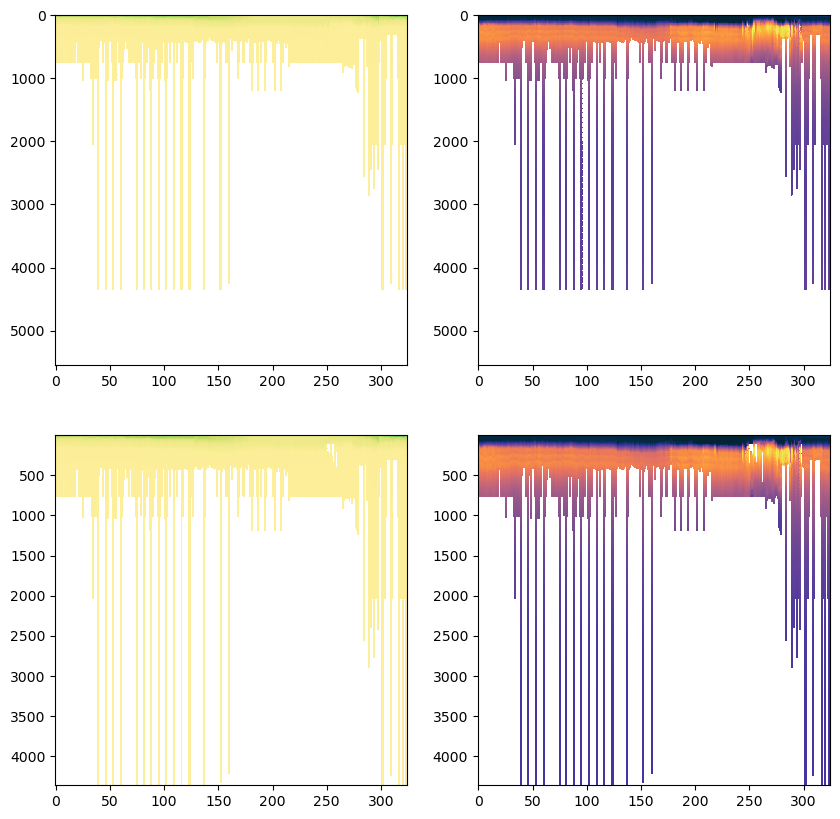

In [11]:
f,ax = plt.subplots(2,2,figsize=[10,10])

prof_num = np.arange(0,PSAL.shape[0],1)
ax=ax.ravel()
ax[0].pcolor(prof_num,zi,PSAL.T,cmap=cmocean.cm.haline)
ax[0].invert_yaxis()

ax[1].pcolor(prof_num,zi,TEMP.T,cmap=cmocean.cm.thermal)
ax[1].invert_yaxis()


ax[2].pcolor(prof_num,ds.depth,ds.salinity,cmap=cmocean.cm.haline)
ax[2].invert_yaxis()

ax[3].pcolor(prof_num,ds.depth,ds.temperature,cmap=cmocean.cm.thermal)
ax[3].invert_yaxis()